# **Metro Interstate Traffic Volume Prediction**

This project predicts hourly traffic volume on westbound Interstate 94 using regression models.

The dataset contains traffic, weather, holiday, and time-related information from 2012 to 2018.

The workflow includes exploratory data analysis, time-based feature engineering, categorical encoding, regression modelling, and model evaluation using R², RMSE, and MAE.

**Dataset**

Source: UCI Machine Learning Repository  
Dataset: Metro Interstate Traffic Volume  
Target: `traffic_volume`

<a href='https://archive.ics.uci.edu/dataset/492/urban+traffic' target='_blank'>
Click here for the dataset
</a>

**Data Dictionary**

| Feature | Description |
|---|---|
| holiday | US national or regional holiday |
| temp | Average temperature in Kelvin |
| rain_1h | Rainfall during the hour in mm |
| snow_1h | Snowfall during the hour in mm |
| clouds_all | Percentage of cloud cover |
| weather_main | General weather condition |
| weather_description | Detailed weather description |
| date_time | Date and time of observation |
| traffic_volume | Hourly westbound traffic volume (target) |

<img src="metro_traffic_regression.png" width="900">

<div style="border:1px solid #ddd; border-radius:12px; padding:22px; background:#f8f9fa;">

<h2 style="margin-top:0;">Metro Interstate Traffic Volume Prediction</h2>
<p><b>Regression Workflow</b></p>

<table style="width:100%; text-align:center; border-collapse:separate; border-spacing:8px;">
<tr>

<td style="padding:18px; background:#eaf2ff; border-radius:10px;">
<b>Data</b><br>
Traffic + Weather
</td>

<td style="font-size:24px;">→</td>

<td style="padding:18px; background:#eaf2ff; border-radius:10px;">
<b>Feature Engineering</b><br>
Hour · Day · Month
</td>

<td style="font-size:24px;">→</td>

<td style="padding:18px; background:#eaf2ff; border-radius:10px;">
<b>Regression Models</b><br>
Linear · Random Forest
</td>

<td style="font-size:24px;">→</td>

<td style="padding:18px; background:#eaf2ff; border-radius:10px;">
<b>Evaluation</b><br>
R² · RMSE · MAE
</td>

<td style="font-size:24px;">→</td>

<td style="padding:18px; background:#eaf2ff; border-radius:10px;">
<b>Prediction</b><br>
Traffic Volume
</td>

</tr>
</table>

</div>

**Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load Data**

In [3]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


**Exploratory Data Analysis**

In [4]:
df.shape

(48204, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


In [6]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(17)

In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000
mean,281.204995,0.334382,0.000222,49.365451,3259.618134
std,13.338738,44.797033,0.008169,39.015213,1986.954465
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1192.500000
50%,282.450000,0.000000,0.000000,64.000000,3379.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


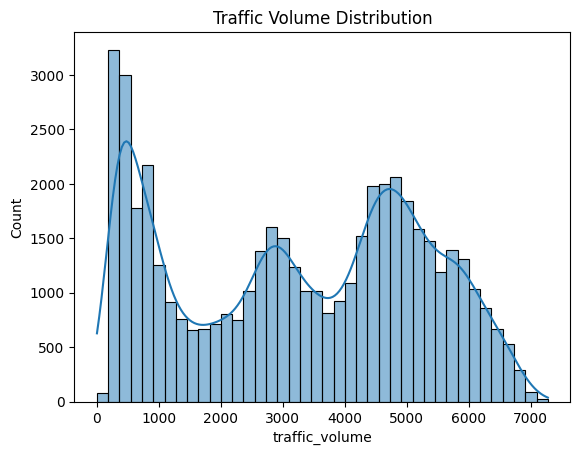

In [10]:
#Target Distribution

sns.histplot(df["traffic_volume"], bins=40, kde=True)

plt.title("Traffic Volume Distribution")
plt.show()

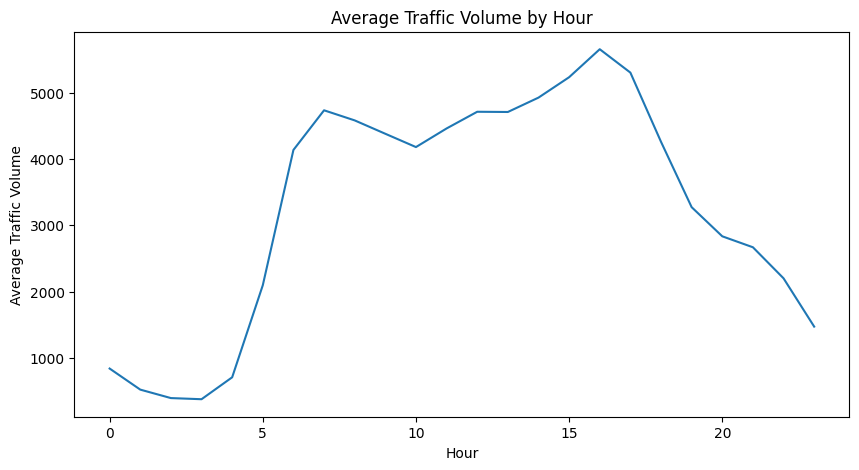

In [11]:
#Traffic by Hour

df["date_time"] = pd.to_datetime(df["date_time"])

df["hour"] = df["date_time"].dt.hour

hourly_traffic = df.groupby("hour")["traffic_volume"].mean()

hourly_traffic.plot(figsize=(10, 5))

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Traffic Volume")
plt.show()

**Feature Engineering**

Time-related features are extracted from `date_time` to capture daily and seasonal traffic patterns.

In [12]:
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month
df["year"] = df["date_time"].dt.year

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_holiday"] = df["holiday"].notna().astype(int)

**Data Preparation**

Categorical weather information is converted into numerical variables using one-hot encoding.

In [16]:
features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "weather_main",
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend",
    "is_holiday"
]

x = pd.get_dummies(
    df[features],
    columns=["weather_main"],
    drop_first=True
)

y = df["traffic_volume"]

*Train-Test Split*

In [17]:
df = df.sort_values("date_time")

x = x.loc[df.index]
y = y.loc[df.index]

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    shuffle=False
)

**Model Training**

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

linear_model = LinearRegression()
rf_model = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

In [21]:
linear_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [25]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [29]:
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)

    print("R²:", round(r2_score(y_test, y_pred), 3))
    print("RMSE:", round(mean_squared_error(y_test, y_pred)**0.5, 2))
    print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))

    return y_pred

In [30]:
print("Linear Regression")
linear_pred = evaluate_model(linear_model, x_test, y_test)

Linear Regression
R²: 0.195
RMSE: 1765.71
MAE: 1547.7


In [31]:
print("Random Forest")
rf_pred = evaluate_model(rf_model, x_test, y_test)

Random Forest
R²: 0.925
RMSE: 538.69
MAE: 309.99


**Actual vs Predicted**

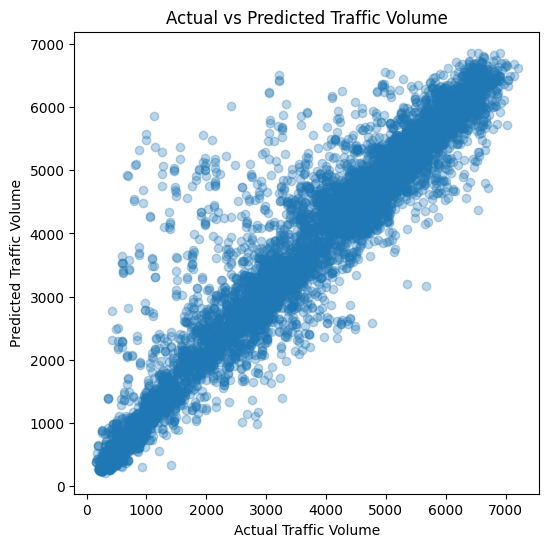

In [28]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, rf_pred, alpha=0.3)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic Volume")

plt.show()

**Feature Importance**

In [32]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,hour,0.829149
5,day_of_week,0.059614
8,is_weekend,0.050353
0,temp,0.029091
6,month,0.010493
7,year,0.007509
3,clouds_all,0.006046
1,rain_1h,0.002761
10,weather_main_Clouds,0.001859
14,weather_main_Mist,0.000746


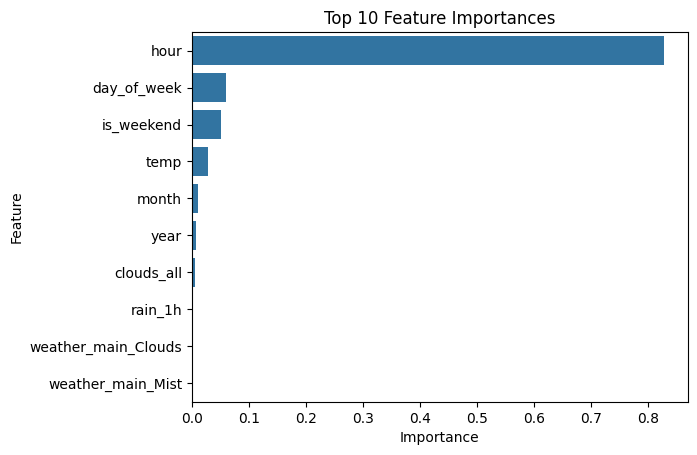

In [33]:
top_features = feature_importance.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.show()

**Summary**

This project used regression models to predict hourly traffic volume on Interstate 94.

Time-related features such as hour, day of the week, month, and weekend status were created from the original datetime variable. Weather information was also included in the modelling process.

Linear Regression achieved an R² score of 0.195, while Random Forest achieved an R² score of 0.925 with an RMSE of 538.69 and an MAE of 309.99.

The results show that Random Forest captured the traffic patterns substantially better than Linear Regression. Feature importance also showed that `hour` was the most influential predictor, followed by `day_of_week`, `is_weekend`, and `temp`.

Overall, the project demonstrates that traffic volume is strongly associated with temporal patterns and nonlinear relationships.